In [1]:
#------使用XGB模型-透射光谱-使用光谱预处理方法-融合RGB------#
#------储存路径代号：XGB_Fusion_02------#

In [2]:
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from utils.train_log import EvaluationMetricsLogger,PredictionSaver
from utils import datalodaer,model_trainer,preprocess,utils,ploter

import pandas as pd
import numpy as np
from datetime import datetime

# 设置全局字体为 "Times New Roman"
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 9         # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 设置支持负号显示
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

series_path = '06-XGBoost-TS&HIS-Preprocessing'

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
labels_file = project_root / 'data/labels'
image_features_path = project_root / 'data/pictures/histogram_features.csv'
logger = EvaluationMetricsLogger()
saver = PredictionSaver()


加载现有日志文件: ../results/model_evaluation/evaluation_metrics_log.csv，包含 630 条记录
加载现有预测文件: ../results/model_evaluation/predictions_log.csv，包含 4650 条预测记录


In [4]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

[I 2026-02-26 21:45:32,617] A new study created in memory with name: xgb_optuna_tuning


NO.1 [正在训练: PH | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 72
  最优参数: {'learning_rate': 0.05677285139395266, 'max_depth': 5, 'min_child_weight': 8.025780002364513, 'subsample': 0.5538587309049974, 'colsample_bytree': 0.8449786485179903, 'reg_lambda': 0.023113480965440737, 'reg_alpha': 0.003465807449616453, 'gamma': 0.036174329416218204}
  最优验证集 RMSE: 0.09442305564880371
  对应 best_iteration: 27
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.6095, 验证集 R²: 0.4213, 测试集 R²: 0.2969



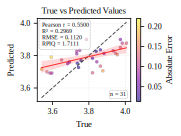

NO.2 [正在训练: PH | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 22
  最优参数: {'learning_rate': 0.018594540695241434, 'max_depth': 7, 'min_child_weight': 3.8847384653710173, 'subsample': 0.7082790818032587, 'colsample_bytree': 0.7224580457826563, 'reg_lambda': 0.03019073239271295, 'reg_alpha': 0.1099074566326115, 'gamma': 0.0012039972377606532}
  最优验证集 RMSE: 0.08642911165952682
  对应 best_iteration: 219
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9589, 验证集 R²: 0.5151, 测试集 R²: 0.4370



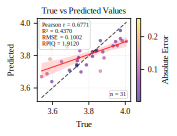

NO.3 [正在训练: PH | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.031196914158464067, 'max_depth': 5, 'min_child_weight': 9.425902620350714, 'subsample': 0.5276391922343526, 'colsample_bytree': 0.9658686274411205, 'reg_lambda': 0.0038399491470875887, 'reg_alpha': 0.01080017490789902, 'gamma': 0.0052817158460494625}
  最优验证集 RMSE: 0.10272111743688583
  对应 best_iteration: 286
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9459, 验证集 R²: 0.3151, 测试集 R²: 0.2840



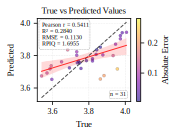

NO.4 [正在训练: PH | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 92
  最优参数: {'learning_rate': 0.02744824834642203, 'max_depth': 6, 'min_child_weight': 2.9251448085693537, 'subsample': 0.5375131833640528, 'colsample_bytree': 0.8620830949477447, 'reg_lambda': 0.049344563979682295, 'reg_alpha': 0.011250781949367638, 'gamma': 0.044791482804781166}
  最优验证集 RMSE: 0.10410089790821075
  对应 best_iteration: 113
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.7852, 验证集 R²: 0.2966, 测试集 R²: 0.3301



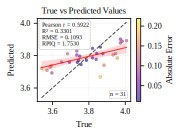

NO.5 [正在训练: PH | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 25
  最优参数: {'learning_rate': 0.06830722417428445, 'max_depth': 8, 'min_child_weight': 6.403889612535535, 'subsample': 0.7048143740473232, 'colsample_bytree': 0.8703790683541198, 'reg_lambda': 0.01650251202963039, 'reg_alpha': 0.009650937966264315, 'gamma': 0.005000479628619818}
  最优验证集 RMSE: 0.07324542850255966
  对应 best_iteration: 171
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9806, 验证集 R²: 0.6518, 测试集 R²: 0.6803



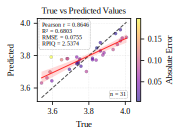

NO.6 [正在训练: PH | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.0900628643154499, 'max_depth': 5, 'min_child_weight': 4.277162590704881, 'subsample': 0.6927194162946602, 'colsample_bytree': 0.8935003998436175, 'reg_lambda': 0.013280608379542376, 'reg_alpha': 0.005874194027390046, 'gamma': 0.00015457083878103826}
  最优验证集 RMSE: 0.0608665905892849
  对应 best_iteration: 40
预测结果已保存OK
实验记录已保存: PH-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9917, 验证集 R²: 0.7595, 测试集 R²: 0.6549



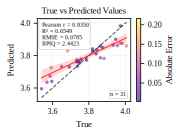

NO.7 [正在训练: GLU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 66
  最优参数: {'learning_rate': 0.06100389481911118, 'max_depth': 8, 'min_child_weight': 7.91679582644873, 'subsample': 0.8725369601022489, 'colsample_bytree': 0.4233554186787979, 'reg_lambda': 29.998041261860465, 'reg_alpha': 0.3233415907505098, 'gamma': 0.15268559079663033}
  最优验证集 RMSE: 1.7675864696502686
  对应 best_iteration: 105
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.8624, 验证集 R²: 0.6753, 测试集 R²: 0.5987



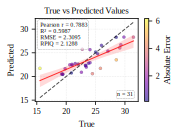

NO.8 [正在训练: GLU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 89
  最优参数: {'learning_rate': 0.02992209717056876, 'max_depth': 2, 'min_child_weight': 8.16169996822323, 'subsample': 0.550936746651399, 'colsample_bytree': 0.9036668059975632, 'reg_lambda': 0.7158636297583089, 'reg_alpha': 0.31659848074771774, 'gamma': 0.48072328808813625}
  最优验证集 RMSE: 1.5351396799087524
  对应 best_iteration: 489
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9857, 验证集 R²: 0.7551, 测试集 R²: 0.7213



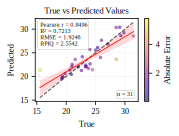

NO.9 [正在训练: GLU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 65
  最优参数: {'learning_rate': 0.061614219849975976, 'max_depth': 5, 'min_child_weight': 7.838195206510324, 'subsample': 0.6322995692126862, 'colsample_bytree': 0.38370304095596897, 'reg_lambda': 0.0043190668519140565, 'reg_alpha': 0.19030861508029717, 'gamma': 2.461258760270103}
  最优验证集 RMSE: 1.48358952999115
  对应 best_iteration: 76
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9458, 验证集 R²: 0.7713, 测试集 R²: 0.6938



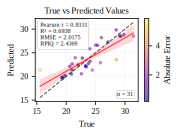

NO.10 [正在训练: GLU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 86
  最优参数: {'learning_rate': 0.0738090435450704, 'max_depth': 2, 'min_child_weight': 6.419591172953719, 'subsample': 0.5644591252592687, 'colsample_bytree': 0.9978055609734526, 'reg_lambda': 0.00996481951885431, 'reg_alpha': 0.6535548125651043, 'gamma': 1.4673690808807272}
  最优验证集 RMSE: 1.4743837118148804
  对应 best_iteration: 227
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9724, 验证集 R²: 0.7741, 测试集 R²: 0.6969



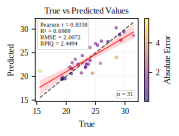

NO.11 [正在训练: GLU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 96
  最优参数: {'learning_rate': 0.028159403994865388, 'max_depth': 2, 'min_child_weight': 1.007972424162026, 'subsample': 0.5392134837778193, 'colsample_bytree': 0.3620663311390237, 'reg_lambda': 26.36148472689102, 'reg_alpha': 0.3670211673562339, 'gamma': 0.028419756723616074}
  最优验证集 RMSE: 1.467114806175232
  对应 best_iteration: 1051
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9886, 验证集 R²: 0.7763, 测试集 R²: 0.7480



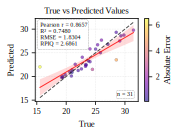

NO.12 [正在训练: GLU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 99
  最优参数: {'learning_rate': 0.003720012879740743, 'max_depth': 2, 'min_child_weight': 9.71005654467299, 'subsample': 0.5002567548306972, 'colsample_bytree': 0.7484499244371469, 'reg_lambda': 0.20043285663258167, 'reg_alpha': 0.8238814436156785, 'gamma': 0.6585834369705568}
  最优验证集 RMSE: 1.3279377222061157
  对应 best_iteration: 2790
预测结果已保存OK
实验记录已保存: GLU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9828, 验证集 R²: 0.8167, 测试集 R²: 0.7806



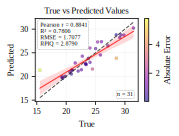

NO.13 [正在训练: 5-HMF | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 97
  最优参数: {'learning_rate': 0.09432759056246626, 'max_depth': 3, 'min_child_weight': 6.832401558572723, 'subsample': 0.9040014937247213, 'colsample_bytree': 0.9559916413485455, 'reg_lambda': 0.002811665446937502, 'reg_alpha': 0.0037930139369766664, 'gamma': 4.04594813489427}
  最优验证集 RMSE: 26.419641494750977
  对应 best_iteration: 31
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9499, 验证集 R²: 0.9459, 测试集 R²: 0.6400



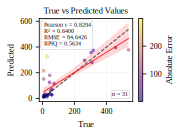

NO.14 [正在训练: 5-HMF | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 23
  最优参数: {'learning_rate': 0.04313126811643065, 'max_depth': 6, 'min_child_weight': 4.185209303201953, 'subsample': 0.9456930064523473, 'colsample_bytree': 0.9901939134324654, 'reg_lambda': 0.07640273815364455, 'reg_alpha': 0.0022483066052387973, 'gamma': 3.0917656945514866}
  最优验证集 RMSE: 24.771757125854492
  对应 best_iteration: 94
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9906, 验证集 R²: 0.9524, 测试集 R²: 0.7608



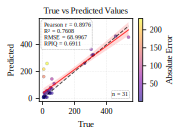

NO.15 [正在训练: 5-HMF | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 60
  最优参数: {'learning_rate': 0.009191502154722753, 'max_depth': 7, 'min_child_weight': 2.519420921633582, 'subsample': 0.788608145240265, 'colsample_bytree': 0.9422007940915587, 'reg_lambda': 97.68678597598465, 'reg_alpha': 0.00433255637123167, 'gamma': 3.079345323456963}
  最优验证集 RMSE: 22.19316864013672
  对应 best_iteration: 4963
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9771, 验证集 R²: 0.9618, 测试集 R²: 0.7868



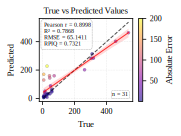

NO.16 [正在训练: 5-HMF | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 55
  最优参数: {'learning_rate': 0.004954355664861071, 'max_depth': 3, 'min_child_weight': 7.605819948021631, 'subsample': 0.9530615499066069, 'colsample_bytree': 0.764560762820462, 'reg_lambda': 64.25987382503405, 'reg_alpha': 0.002462720295002553, 'gamma': 3.1829798514694936}
  最优验证集 RMSE: 22.81650733947754
  对应 best_iteration: 3735
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9435, 验证集 R²: 0.9597, 测试集 R²: 0.7521



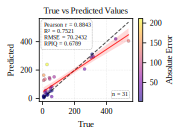

NO.17 [正在训练: 5-HMF | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 89
  最优参数: {'learning_rate': 0.025992772664739427, 'max_depth': 2, 'min_child_weight': 9.967705263098003, 'subsample': 0.6100556495188352, 'colsample_bytree': 0.5728121389289924, 'reg_lambda': 28.895772227992868, 'reg_alpha': 0.004934446241884614, 'gamma': 2.3385947147044965}
  最优验证集 RMSE: 34.49449920654297
  对应 best_iteration: 986
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9784, 验证集 R²: 0.9078, 测试集 R²: 0.8364



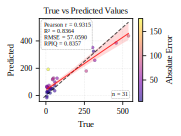

NO.18 [正在训练: 5-HMF | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.06572641780110747, 'max_depth': 5, 'min_child_weight': 1.5516610912156854, 'subsample': 0.9884799388447123, 'colsample_bytree': 0.9641736112000411, 'reg_lambda': 0.5160505604504879, 'reg_alpha': 3.3259403233179907, 'gamma': 0.3713599718475334}
  最优验证集 RMSE: 19.06627655029297
  对应 best_iteration: 30
预测结果已保存OK
实验记录已保存: 5-HMF-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9726, 验证集 R²: 0.9718, 测试集 R²: 0.8654



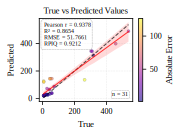

NO.19 [正在训练: Water | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 97
  最优参数: {'learning_rate': 0.004986438281867435, 'max_depth': 3, 'min_child_weight': 3.8552545739713144, 'subsample': 0.6520088676800944, 'colsample_bytree': 0.4482714642100784, 'reg_lambda': 10.115783881041544, 'reg_alpha': 0.17616581044638116, 'gamma': 0.11868490624776161}
  最优验证集 RMSE: 0.8372377753257751
  对应 best_iteration: 2971
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9944, 验证集 R²: 0.9630, 测试集 R²: 0.9713



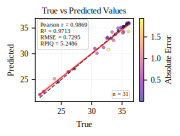

NO.20 [正在训练: Water | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.0016960264306203128, 'max_depth': 8, 'min_child_weight': 9.623828784389104, 'subsample': 0.7394381013555872, 'colsample_bytree': 0.5824176625888708, 'reg_lambda': 0.014715103855481764, 'reg_alpha': 0.0018128562930735455, 'gamma': 0.028771527671758612}
  最优验证集 RMSE: 0.91818767786026
  对应 best_iteration: 2527
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9910, 验证集 R²: 0.9555, 测试集 R²: 0.9654



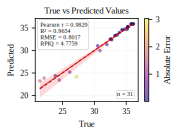

NO.21 [正在训练: Water | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 65
  最优参数: {'learning_rate': 0.002739364143368403, 'max_depth': 5, 'min_child_weight': 3.604771794287525, 'subsample': 0.6020059644813324, 'colsample_bytree': 0.9869490497835958, 'reg_lambda': 2.5526898125055606, 'reg_alpha': 0.05601589735775148, 'gamma': 0.5827865119619404}
  最优验证集 RMSE: 0.7295883893966675
  对应 best_iteration: 2571
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9953, 验证集 R²: 0.9719, 测试集 R²: 0.9462



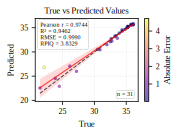

NO.22 [正在训练: Water | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 63
  最优参数: {'learning_rate': 0.017221914380123424, 'max_depth': 5, 'min_child_weight': 1.2158210603544881, 'subsample': 0.5405889851597049, 'colsample_bytree': 0.7449275950364849, 'reg_lambda': 0.8135830837583369, 'reg_alpha': 0.023037318700210065, 'gamma': 0.09322093041954359}
  最优验证集 RMSE: 0.577835738658905
  对应 best_iteration: 574
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9991, 验证集 R²: 0.9824, 测试集 R²: 0.9813



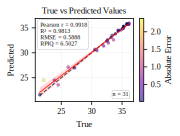

NO.23 [正在训练: Water | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 42
  最优参数: {'learning_rate': 0.007749782925754971, 'max_depth': 5, 'min_child_weight': 7.613626751705961, 'subsample': 0.6948812336827179, 'colsample_bytree': 0.4506201847456437, 'reg_lambda': 0.20126238201170646, 'reg_alpha': 0.023292604024438505, 'gamma': 0.705889539861416}
  最优验证集 RMSE: 0.6196271777153015
  对应 best_iteration: 1390
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9973, 验证集 R²: 0.9797, 测试集 R²: 0.9880



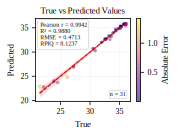

NO.24 [正在训练: Water | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 56
  最优参数: {'learning_rate': 0.034282989541466635, 'max_depth': 6, 'min_child_weight': 7.227989004345558, 'subsample': 0.5918963853460742, 'colsample_bytree': 0.8396893748017801, 'reg_lambda': 0.03687989927322288, 'reg_alpha': 0.004212945180057303, 'gamma': 1.152536475979283}
  最优验证集 RMSE: 0.5861663818359375
  对应 best_iteration: 246
预测结果已保存OK
实验记录已保存: Water-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9956, 验证集 R²: 0.9819, 测试集 R²: 0.9857



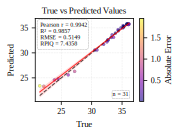

NO.25 [正在训练: FRU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 59
  最优参数: {'learning_rate': 0.05745954677296947, 'max_depth': 7, 'min_child_weight': 9.536726255008702, 'subsample': 0.7367514810675939, 'colsample_bytree': 0.9021811982668033, 'reg_lambda': 12.748531291724634, 'reg_alpha': 0.023220677960136177, 'gamma': 3.1311781329590884}
  最优验证集 RMSE: 2.4375226497650146
  对应 best_iteration: 61
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.7798, 验证集 R²: 0.6626, 测试集 R²: 0.5151



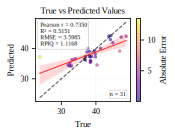

NO.26 [正在训练: FRU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 65
  最优参数: {'learning_rate': 0.08261649145666836, 'max_depth': 5, 'min_child_weight': 9.228300867653752, 'subsample': 0.994572051391057, 'colsample_bytree': 0.6154457915010257, 'reg_lambda': 0.17810130875751243, 'reg_alpha': 0.021229055622860288, 'gamma': 3.342915972650994}
  最优验证集 RMSE: 2.43481183052063
  对应 best_iteration: 20
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.8695, 验证集 R²: 0.6634, 测试集 R²: 0.5880



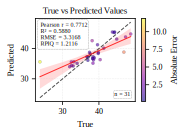

NO.27 [正在训练: FRU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 76
  最优参数: {'learning_rate': 0.09072129876349544, 'max_depth': 2, 'min_child_weight': 2.306085060717304, 'subsample': 0.8538589942107789, 'colsample_bytree': 0.7535998626817063, 'reg_lambda': 0.028244382703411553, 'reg_alpha': 0.002748900348808849, 'gamma': 2.922451026419682}
  最优验证集 RMSE: 2.3294639587402344
  对应 best_iteration: 209
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9772, 验证集 R²: 0.6919, 测试集 R²: 0.5893



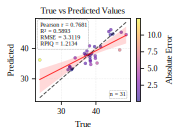

NO.28 [正在训练: FRU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 91
  最优参数: {'learning_rate': 0.0021099431376149537, 'max_depth': 7, 'min_child_weight': 1.3288690813425132, 'subsample': 0.9999793445317767, 'colsample_bytree': 0.8424369717579147, 'reg_lambda': 0.05772238097828457, 'reg_alpha': 0.004281141118119805, 'gamma': 0.16444051455144043}
  最优验证集 RMSE: 2.2456448078155518
  对应 best_iteration: 733
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9443, 验证集 R²: 0.7137, 测试集 R²: 0.5942



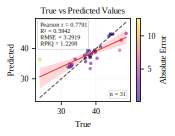

NO.29 [正在训练: FRU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 86
  最优参数: {'learning_rate': 0.0992311445314597, 'max_depth': 2, 'min_child_weight': 4.5299227868699745, 'subsample': 0.6919703146236769, 'colsample_bytree': 0.625303777700152, 'reg_lambda': 0.06132130503965576, 'reg_alpha': 3.5453404919356206, 'gamma': 0.06237666026446814}
  最优验证集 RMSE: 2.239297389984131
  对应 best_iteration: 114
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9882, 验证集 R²: 0.7153, 测试集 R²: 0.5329



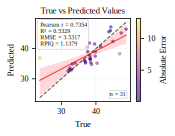

NO.30 [正在训练: FRU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 76
  最优参数: {'learning_rate': 0.008572086368819922, 'max_depth': 2, 'min_child_weight': 2.5112890807901027, 'subsample': 0.5131798484444099, 'colsample_bytree': 0.9336442509737861, 'reg_lambda': 0.5543391438799727, 'reg_alpha': 0.034647514315086905, 'gamma': 3.3364286908774776}
  最优验证集 RMSE: 2.1026296615600586
  对应 best_iteration: 1118
预测结果已保存OK
实验记录已保存: FRU-06-XGBoost-TS&HIS-Preprocessing
训练集 R²: 0.9856, 验证集 R²: 0.7490, 测试集 R²: 0.6276



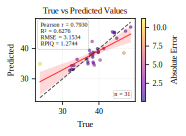

所有模型及预处理对比训练完成！


In [5]:
# 遍历所有 Label 文件
i = 0
for filename in os.listdir(labels_file):
    if filename.endswith(('.csv',)):
        label_path = os.path.join(labels_file, filename)
        label_name = os.path.splitext(filename)[0]

        # 读取并分割数据 (只需做一次)
        try:
            # 1. 加载、对齐数据，并划分数据集
            train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path, image_features_path, label_path)
            # 每个set包含(X_spec, X_image, y, idx)
            # 2. 内部循环：遍历预处理方法
            for prep_name, prep_obj in preprocess_methods.items():
                i += 1
                print(f"NO.{i} [正在训练: {label_name} | 预处理: {prep_name}]========================")

                # =========================================
                # A. 数据融合处理 (关键步骤)
                # =========================================
                # 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
                spec_train_trans = prep_obj.fit_transform(train_set[0])
                spec_val_trans = prep_obj.transform(val_set[0])
                spec_test_trans = prep_obj.transform(test_set[0])

                # 2. 图像特征部分: 标准化 (XGB内无StandardScaler)
                scaler = StandardScaler()
                image_train_trans = scaler.fit_transform(train_set[1])
                image_val_trans = scaler.transform(val_set[1])
                image_test_trans = scaler.transform(test_set[1])

                # 3. 特征级融合 (Concatenation)
                X_train_fused = np.hstack([spec_train_trans, image_train_trans])
                X_val_fused = np.hstack([spec_val_trans, image_val_trans])
                X_test_fused = np.hstack([spec_test_trans, image_test_trans])

                # 4. 构建数据元组
                fused_train_set = (X_train_fused, train_set[2])
                fused_val_set = (X_val_fused, val_set[2])
                fused_test_set = (X_test_fused, test_set[2])

                # =========================================
                # B. 模型 2: XGBoost 回归
                # =========================================
                # 1. 构造路径名，包含预处理信息
                model_name = series_path
                notes = f"XGBoost + 透射光谱&HIS + {prep_name} 预处理"
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                figure_name = f"Fig_{series_path}-({label_name}; {prep_name})_{timestamp}"

                # 2. 使用 Optuna 寻找最优超参数 (使用处理后的数据)
                best_model, evaluation = model_trainer.tune_xgb_optuna(fused_train_set, fused_val_set)

                # 3. 预测 (使用处理后的数据)
                y_train_pred = best_model.predict(X_train_fused)
                y_val_pred = best_model.predict(X_val_fused)
                y_test_pred = best_model.predict(X_test_fused)

                # 4. 保存预测结果到csv文件
                results_df = pd.DataFrame({
                    'index': test_set[3],
                    'true_value': test_set[2],
                    'predicted_value': y_test_pred
                })
                results_df['label_name'] = label_name
                results_df['model_name'] = notes
                results_df['prediction_time'] = timestamp
                saver.save_prediction(results_df)

                # 6. 评估
                train_r, train_rmse, train_r2, train_rpiq, train_mae = utils.evaluate_model(train_set[2], y_train_pred)
                val_r, val_rmse, val_r2, val_rpiq, val_mae = utils.evaluate_model(val_set[2], y_val_pred)
                test_r, test_rmse, test_r2, test_rpiq, test_mae = utils.evaluate_model(test_set[2], y_test_pred)

                # 7. 创建当前实验的数据字典
                metrics_data = {
                    'Timestamp': [timestamp, timestamp, timestamp],
                    'Experiment': [label_name, label_name, label_name],
                    'Model': [model_name, model_name, model_name],
                    'Dataset': ['Training', 'Validation', 'Test'],
                    'Pearson_r': [train_r, val_r, test_r],
                    'RMSE': [train_rmse, val_rmse, test_rmse],
                    'R2': [train_r2, val_r2, test_r2],
                    'RPIQ': [train_rpiq, val_rpiq, test_rpiq],
                    'MAE': [train_mae, val_mae, test_mae],
                    'Notes': [notes, notes, notes]
                }
                # 8. 记录实验结果
                logger.log_metrics(metrics_data, model_name, label_name, parameters=evaluation)  # 记录日志
                ploter.correlation_scatter(6.5, 5, test_set[2], y_test_pred, figure_name)

        except Exception as e:
            print(f"执行失败: {filename} - 错误: {str(e)}")

print("所有模型及预处理对比训练完成！")